# Medical Insurance Cost Prediction

## Machine Learning Regression Project

### Objective
To build a machine learning model that predicts medical insurance charges based on demographic and health-related features.

## Project Workflow

1. Import Libraries
2. Load Dataset
3. Understand the Dataset
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Data Preprocessing
7. Train-Test Split
8. Train Regression Models
9. Evaluate Models
10. Hyperparameter Tuning
11. Feature Importance Analysis
12. Predict Insurance Charges for New Data
13. Conclusion

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [162]:
df = pd.read_csv('/content/insurance.csv')

In [163]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [164]:
df.shape

(1338, 7)

In [165]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [167]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [168]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [169]:
print(df["sex"].unique())
print(df["smoker"].unique())
print(df["region"].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


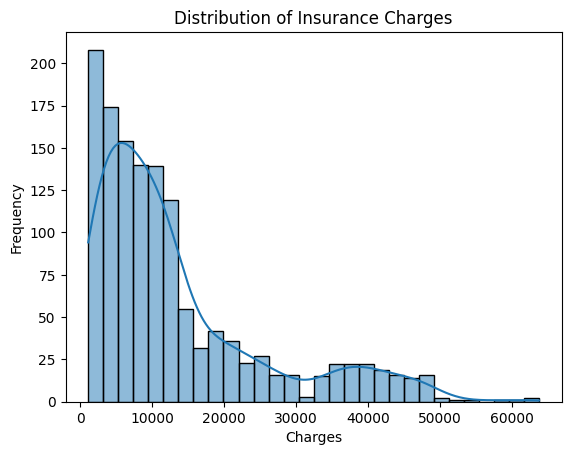

In [170]:
# Distribution of insurance charges

sns.histplot(df["charges"], kde= True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

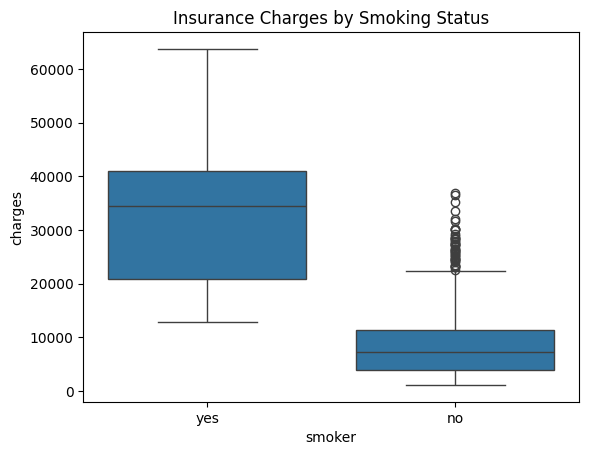

In [171]:
# 2.Charges by Smoker Status
sns.boxplot(x='smoker', y="charges", data=df)
plt.title("Insurance Charges by Smoking Status")
plt.show()

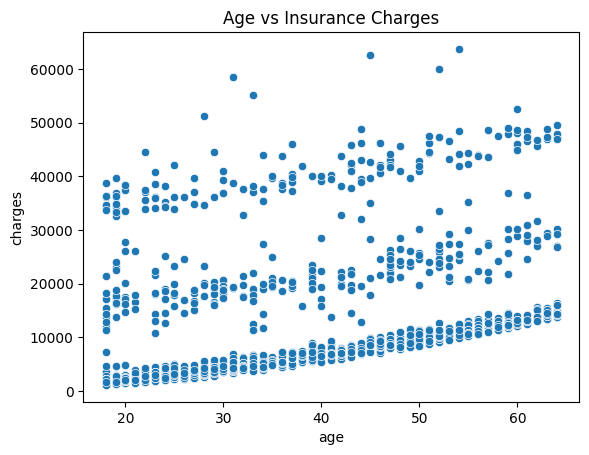

In [172]:
# 3.Charges vs Age

sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Insurance Charges")
plt.show()

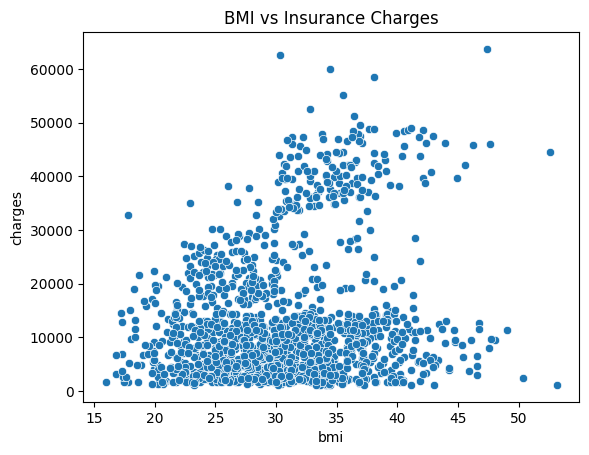

In [173]:
# 4.Charges vs BMI

sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

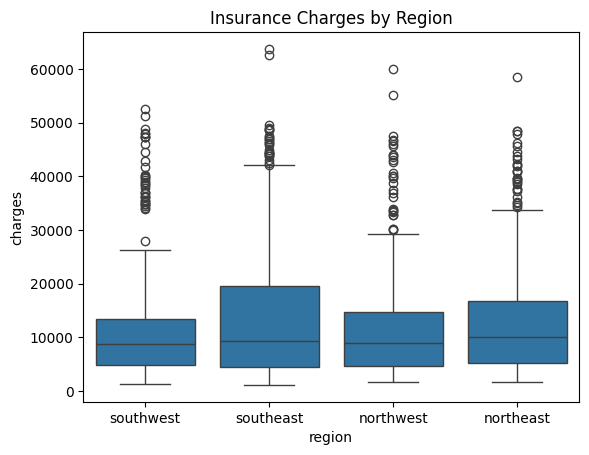

In [174]:
# 5.Charges by Region
sns.boxplot(x='region', y='charges', data=df)
plt.title("Insurance Charges by Region")
plt.show()

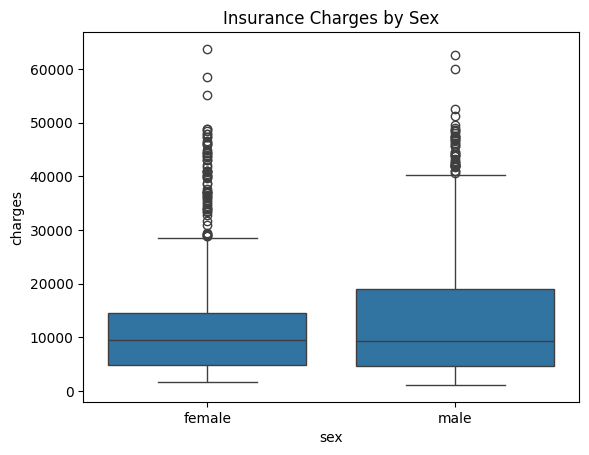

In [175]:
# 6.Charges by sex
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Insurance Charges by Sex")
plt.show()

In [176]:
corr = df[["age", "bmi", "children", "charges"]].corr()
corr

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


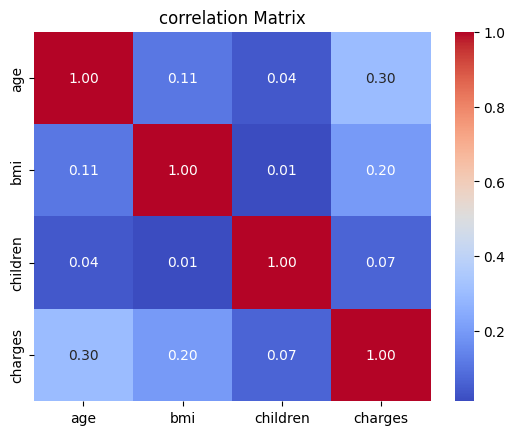

In [177]:
plt.figure()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"

)

plt.title("correlation Matrix")
plt.show()

In [178]:
# 1. seperate X and y

X = df.drop("charges", axis=1)
y = df["charges"]

In [179]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [180]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [181]:
# 2.Train/Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [182]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 6)
(268, 6)
(1070,)
(268,)


In [183]:
from pandas.core.arrays import categorical
# 3.Identify numerical and categorical columns

numerical_features = ["age","bmi","children"]

categorical_features = ["sex","smoker","region"]

In [184]:
# 4. Create the Encoder

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

In [185]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num","passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"),categorical_features)
    ]
)

In [186]:
# Transform the Data

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [187]:
print("Before Preprocessing:", X_train.shape)
print("After preprocessing:", X_train_processed.shape)

print("Test before:", X_test.shape)
print("Test after:", X_test_processed.shape)

Before Preprocessing: (1070, 6)
After preprocessing: (1070, 8)
Test before: (268, 6)
Test after: (268, 8)


In [188]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled= scaler.fit_transform(X_train_processed)
X_test_scaled= scaler.transform(X_test_processed)

In [189]:
# First Model--Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

In [190]:
# Make predictions

y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [191]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "predicted": y_pred
})

print(comparison.head(10))


        Actual     predicted
0   9095.06825   8969.550274
1   5272.17580   7068.747443
2  29330.98315  36858.410912
3   9301.89355   9454.678501
4  33750.29180  26973.173457
5   4536.25900  10864.113164
6   2117.33885    170.280841
7  14210.53595  16903.450287
8   3732.62510   1092.430936
9  10264.44210  11218.343184


In [192]:
# Calculate regression metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4181.1944737536505
MSE: 33596915.851361476
RMSE: 5796.284659276274
R2: 0.7835929767120722


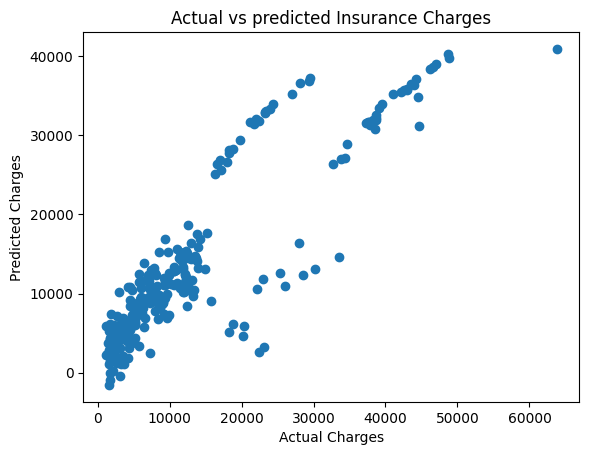

In [193]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs predicted Insurance Charges")

plt.show()

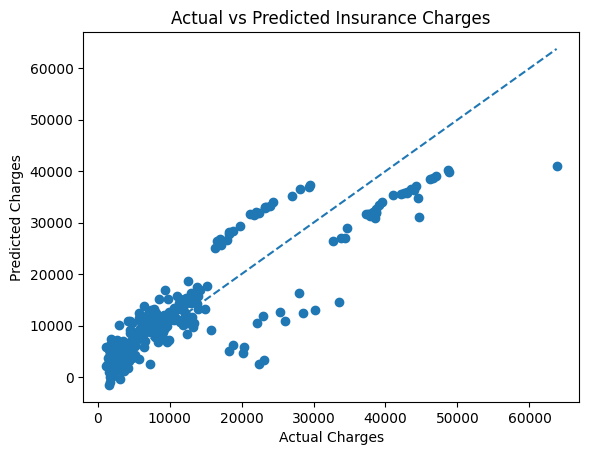

In [194]:
plt.figure()

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()], linestyle ="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

## Ridge Regression

In [195]:
# 1.Train Ridge Regression

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

Ridge()

In [196]:
# 2. Make prediction

ridge_pred = ridge_model.predict(X_test_scaled)

In [197]:
# 3.Evaluate it

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MAE:", ridge_mae)
print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R2:", ridge_r2)

Ridge MAE: 4182.796596583264
Ridge MSE: 33604973.5399633
Ridge RMSE: 5796.979691180856
Ridge R2: 0.7835410749121386


In [198]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)

In [199]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [200]:
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test,lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MAE:", lasso_mae)
print("Lasso MSE:", lasso_mse)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R2:", lasso_r2)

Lasso MAE: 4181.510231838871
Lasso MSE: 33601146.01669809
Lasso RMSE: 5796.649550964599
Lasso R2: 0.7835657290476568


## Decision Tree Regression

In [201]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state= 42,
    max_depth=5
)

tree_model.fit(X_train_processed, y_train)

tree_pred = tree_model.predict(X_test_processed)


In [202]:
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_mse = mean_squared_error(y_test, tree_pred)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R2:", tree_r2)


Decision Tree MAE: 2930.7675712410432
Decision Tree MSE: 25831862.599857908
Decision Tree RMSE: 5082.505543514725
Decision Tree R2: 0.8336098314514943


## Random Forest

In [203]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)

In [204]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 2559.9014228678197
Random Forest MSE: 21039978.52953915
Random Forest RMSE: 4586.935636079838
Random Forest R2: 0.8644756815249467


## Gradient Boosting Regression

In [205]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_processed, y_train)

gb_pred = gb_model.predict(X_test_processed)

In [206]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting MAE: 2457.567910748802
Gradient Boosting MSE: 18576876.88499465
Gradient Boosting RMSE: 4310.090124927163
Gradient Boosting R2: 0.8803412001728399


In [207]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [208]:
# Define the parameter combination

param_grid = {
    "n_estimators" : [100, 200, 300],
    "learning_rate" : [0.03, 0.05, 0.1],
    "max_depth" : [2, 3, 4]
}

In [209]:
# create GridSearchCV

grid_search = GridSearchCV(
    estimator = GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,

    scoring="neg_mean_absolute_error",
    n_jobs = -1




)

In [210]:
grid_search.fit(X_train_processed, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_absolute_error')

In [211]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300}


In [212]:
# Get the best model

best_gb_model = grid_search.best_estimator_

In [213]:
# predict the test set

best_gb_pred = best_gb_model.predict(X_test_processed)

In [214]:
# Calculate the metrics

best_gb_mae = mean_absolute_error(y_test, best_gb_pred)
best_gb_mse = mean_squared_error(y_test, best_gb_pred)
best_gb_rmse = np.sqrt(best_gb_mse)
best_gb_r2 = r2_score(y_test, best_gb_pred)

print("Tuned Gradient Boosting MAE:", best_gb_mae)
print("Tuned Gradient Boosting MSE:", best_gb_mse)
print("Tuned Gradient Boosting RMSE:", best_gb_rmse)
print("Tuned Gradient Boosting R²:", best_gb_r2)

Tuned Gradient Boosting MAE: 2410.631246074706
Tuned Gradient Boosting MSE: 18568369.90369575
Tuned Gradient Boosting RMSE: 4309.103143775483
Tuned Gradient Boosting R²: 0.880395995991248


In [215]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],
    "MAE": [
        mae,
        ridge_mae,
        lasso_mae,
        tree_mae,
        rf_mae,
        gb_mae,
        best_gb_mae
    ],
    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse,
        tree_rmse,
        rf_rmse,
        gb_rmse,
        best_gb_rmse
    ],
    "R2": [
        r2,
        ridge_r2,
        lasso_r2,
        tree_r2,
        rf_r2,
        gb_r2,
        best_gb_r2
    ]
})

print(results)

                     Model          MAE         RMSE        R2
0        Linear Regression  4181.194474  5796.284659  0.783593
1         Ridge Regression  4182.796597  5796.979691  0.783541
2         Lasso Regression  4181.510232  5796.649551  0.783566
3            Decision Tree  2930.767571  5082.505544  0.833610
4            Random Forest  2559.901423  4586.935636  0.864476
5        Gradient Boosting  2457.567911  4310.090125  0.880341
6  Tuned Gradient Boosting  2410.631246  4309.103144  0.880396


In [216]:
results.sort_values("RMSE")

,Model,MAE,RMSE,R2
6,Tuned Gradient Boosting,2410.631246,4309.103144,0.880396
5,Gradient Boosting,2457.567911,4310.090125,0.880341
4,Random Forest,2559.901423,4586.935636,0.864476
3,Decision Tree,2930.767571,5082.505544,0.833610
0,Linear Regression,4181.194474,5796.284659,0.783593
2,Lasso Regression,4181.510232,5796.649551,0.783566
1,Ridge Regression,4182.796597,5796.979691,0.783541


In [218]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__age' 'num__bmi' 'num__children' 'cat__sex_male' 'cat__smoker_yes'
 'cat__region_northwest' 'cat__region_southeast' 'cat__region_southwest']


In [219]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_gb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

                 Feature  Importance
4        cat__smoker_yes    0.695922
1               num__bmi    0.179113
0               num__age    0.115108
2          num__children    0.007731
7  cat__region_southwest    0.001170
6  cat__region_southeast    0.000528
3          cat__sex_male    0.000351
5  cat__region_northwest    0.000078


In [220]:
new_person = pd.DataFrame({
    "age": [35],
    "sex": ["female"],
    "bmi": [28.0],
    "children": [0],
    "smoker": ["no"],
    "region": ["southwest"]
})

new_person

,age,sex,bmi,children,smoker,region
0,35,female,28.0,0,no,southwest


In [221]:
new_person_processed = preprocessor.transform(new_person)

print(new_person_processed)

[[35. 28.  0.  0.  0.  0.  0.  1.]]


In [222]:
prediction = best_gb_model.predict(new_person_processed)

print("Predicted Insurance Charges:", prediction[0])

Predicted Insurance Charges: 6167.672377516783


# Conclusion

In this project, we developed a machine learning model to predict medical insurance charges using demographic and health-related features.

We performed data exploration, data preprocessing, categorical encoding, train-test splitting, model training, evaluation, and hyperparameter tuning.

Several regression models were evaluated, including:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression

After comparing the models, Gradient Boosting performed best on the test set. Hyperparameter tuning using GridSearchCV further improved its performance.

The final tuned Gradient Boosting model achieved:

- MAE: 2410.63
- RMSE: 4309.10
- R²: 0.8804

The feature-importance analysis showed that smoker status was the most influential feature in the model, followed by BMI and age.

Finally, we used the trained model to make a prediction for a new example person, demonstrating how the model can be used to estimate insurance charges for new data.

# Model Performance Summary

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 4181.19 | 5796.28 | 0.7836 |
| Ridge Regression | 4182.80 | 5796.98 | 0.7835 |
| Lasso Regression | 4181.51 | 5796.65 | 0.7836 |
| Decision Tree | 2930.77 | 5082.51 | 0.8336 |
| Random Forest | 2559.90 | 4586.94 | 0.8645 |
| Gradient Boosting | 2457.57 | 4310.09 | 0.8803 |
| Tuned Gradient Boosting | 2410.63 | 4309.10 | 0.8804 |

# Key Findings

- Smoker status was the most important feature in the Gradient Boosting model.
- BMI and age were also important features for predicting insurance charges.
- Tree-based models performed better than the linear models on this dataset.
- Hyperparameter tuning slightly improved the Gradient Boosting model.
- The final tuned model achieved an R² of 0.8804 on the test set.

# Limitations

- The dataset contains a limited set of demographic and health-related features.
- Model predictions are estimates and should not be treated as exact insurance charges.
- Feature importance describes the model's behavior and does not prove causation.
- The model's performance may differ when applied to data from a different population or insurance provider.